# Analisis & Prediksi Telco Customer Churn
**Kelompok 1 — Data Mining**

Notebook ini mendokumentasikan proses pengembangan model machine learning secara *end-to-end* untuk mendeteksi pelanggan telekomunikasi yang berpotensi *churn* (berhenti berlangganan). 

Tahapan yang dicakup:
1. **Exploratory Data Analysis (EDA)**
2. **Data Preprocessing** (penanganan missing values, encoding, standardisasi)
3. **Pembagian Data Latih & Uji**
4. **Pelatihan Model** (Random Forest Classifier)
5. **Evaluasi Performa Model**
6. **Ekspor Model ke Format PKL & JSON** untuk digunakan di backend web

## 1. Import Library & Load Dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import json

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

In [2]:
# Load dataset dari file CSV lokal
DATA_PATH = "telco_customer_churn.csv"
df = pd.read_csv(DATA_PATH)
print(f"Ukuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Ukuran dataset: 7043 baris, 21 kolom


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Exploratory Data Analysis (EDA)

In [3]:
# Deskripsi statistik dari variabel numerik awal
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


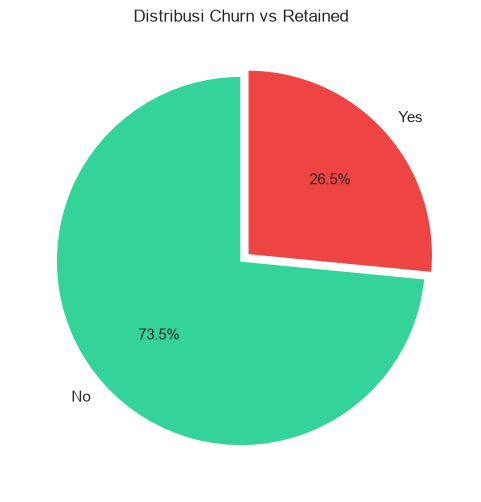

In [4]:
# Visualisasi Distribusi Target Churn
churn_counts = df["Churn"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#34D399', '#EF4444'], explode=[0, 0.05])
plt.title("Distribusi Churn vs Retained")
plt.show()

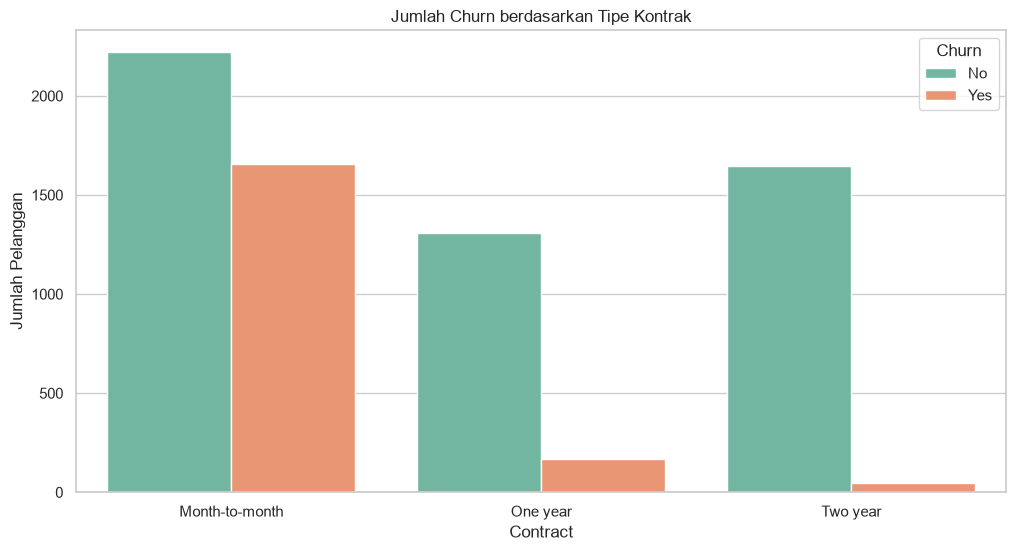

In [5]:
# Visualisasi Pengaruh Kontrak Terhadap Churn
sns.countplot(data=df, x="Contract", hue="Churn", palette="Set2")
plt.title("Jumlah Churn berdasarkan Tipe Kontrak")
plt.ylabel("Jumlah Pelanggan")
plt.show()

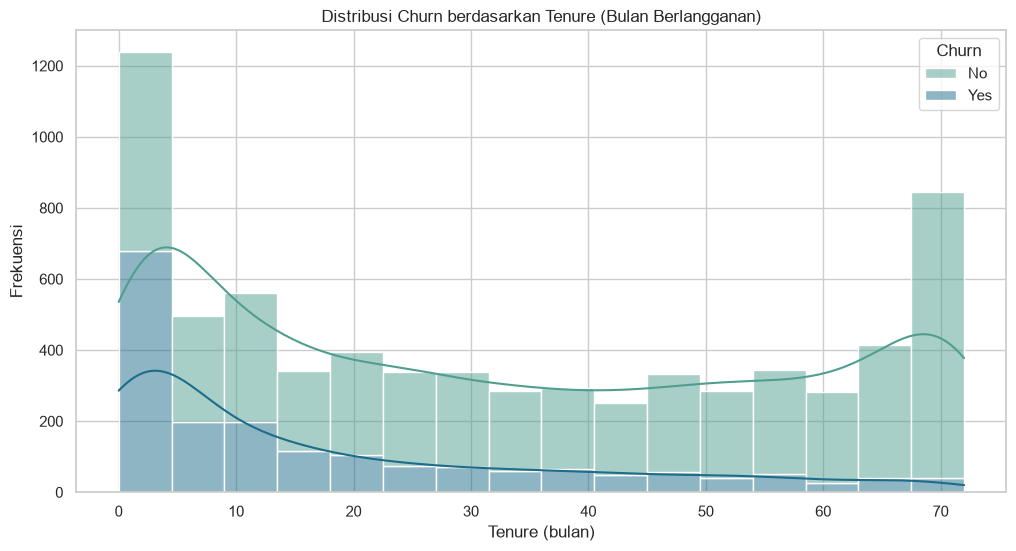

In [6]:
# Visualisasi Pengaruh Tenure Terhadap Churn
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", kde=True, palette="crest")
plt.title("Distribusi Churn berdasarkan Tenure (Bulan Berlangganan)")
plt.xlabel("Tenure (bulan)")
plt.ylabel("Frekuensi")
plt.show()

## 3. Data Preprocessing

In [7]:
# 1. Drop customerID karena tidak bernilai prediktif
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

# 2. Penanganan TotalCharges (terdapat string kosong/spasi)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing_before = df["TotalCharges"].isnull().sum()
print(f"Jumlah nilai kosong pada TotalCharges sebelum imputasi: {missing_before}")

# Imputasi dengan median
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
print(f"Jumlah nilai kosong setelah imputasi: {df['TotalCharges'].isnull().sum()}")

Jumlah nilai kosong pada TotalCharges sebelum imputasi: 11
Jumlah nilai kosong setelah imputasi: 11


/var/folders/xl/_9nvqlhn3qd3jpgfqr_k3p600000gn/T/ipykernel_89817/3601549873.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [8]:
# 3. Encoding target Churn (Yes=1, No=0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop("Churn", axis=1)
y = df["Churn"]

# Identifikasi tipe kolom
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Kolom Kategorikal: {categorical_cols}")
print(f"Kolom Numerik: {numerical_cols}")

Kolom Kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Kolom Numerik: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


/var/folders/xl/_9nvqlhn3qd3jpgfqr_k3p600000gn/T/ipykernel_89817/2097335096.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [9]:
# 4. Label Encoding untuk variabel kategorikal
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# 5. Standardisasi variabel numerik
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,-0.439916,1,0,-1.277445,0,1,0,0,2,0,0,0,0,0,1,2,-1.160323,-0.994194
1,1,-0.439916,0,0,0.066327,1,0,0,2,0,2,0,0,0,1,0,3,-0.259629,-0.173740
2,1,-0.439916,0,0,-1.236724,1,0,0,2,2,0,0,0,0,0,1,3,-0.362660,-0.959649
3,1,-0.439916,0,0,0.514251,0,1,0,2,0,2,2,0,0,1,0,0,-0.746535,-0.195248
4,0,-0.439916,0,0,-1.236724,1,0,1,0,0,0,0,0,0,0,1,2,0.197365,-0.940457


## 4. Pembagian Data & Pelatihan Model

In [10]:
# Split data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Jumlah data training: {X_train.shape[0]} baris")
print(f"Jumlah data testing: {X_test.shape[0]} baris")

Jumlah data training: 5634 baris
Jumlah data testing: 1409 baris


In [11]:
# Pelatihan Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Model Random Forest berhasil dilatih!")

Model Random Forest berhasil dilatih!


## 5. Evaluasi Model

In [12]:
# Prediksi pada data testing
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Churn", "Churn"]))

Akurasi Model: 79.77%

Classification Report:
              precision    recall  f1-score   support

   Not Churn       0.83      0.90      0.87      1035
       Churn       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



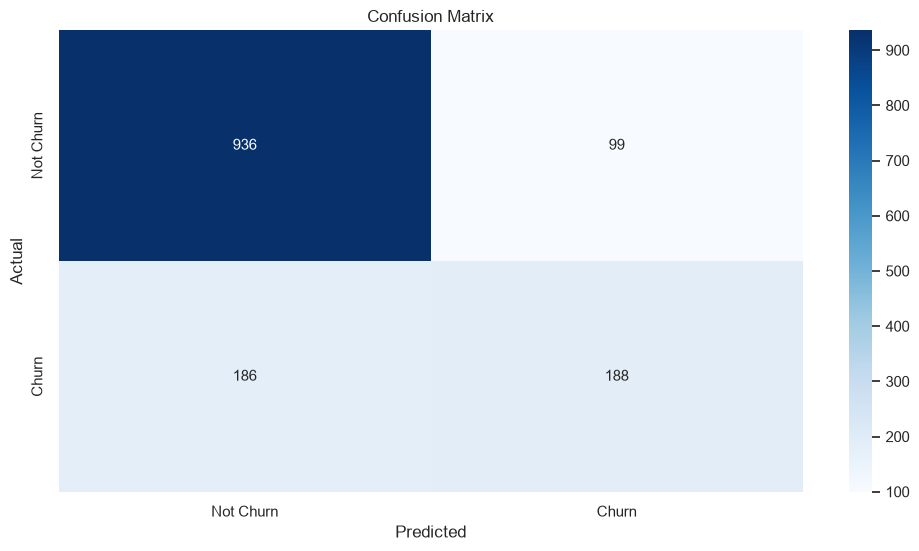

In [13]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/var/folders/xl/_9nvqlhn3qd3jpgfqr_k3p600000gn/T/ipykernel_89817/98270032.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")


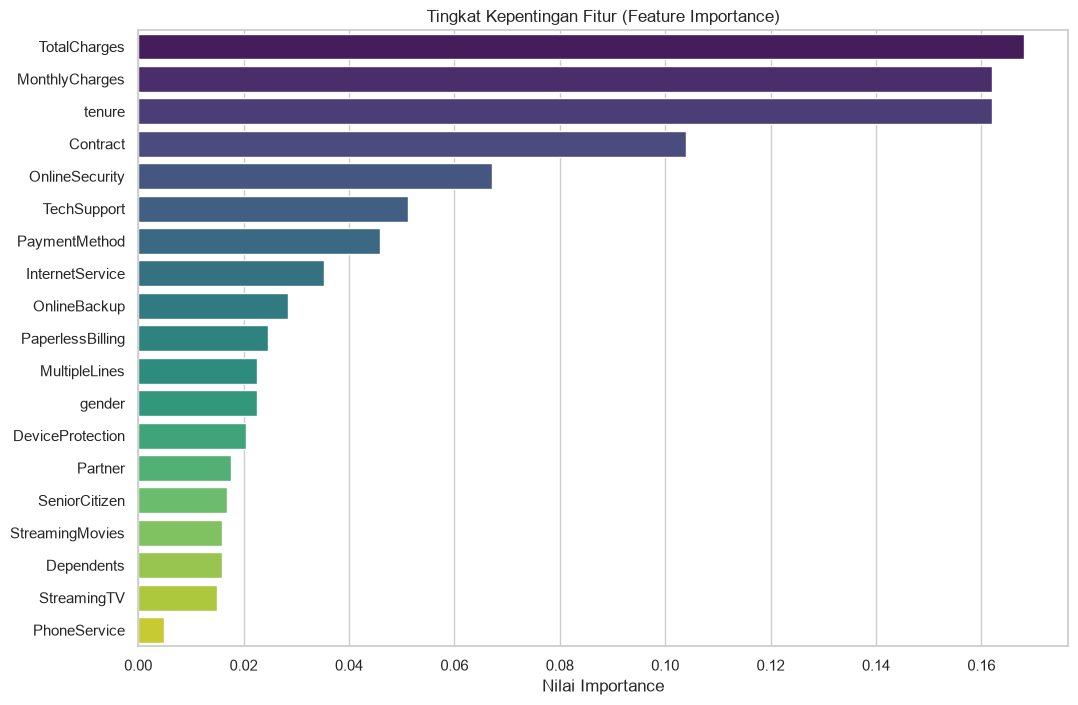

In [14]:
# Visualisasi Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")
plt.title('Tingkat Kepentingan Fitur (Feature Importance)')
plt.xlabel('Nilai Importance')
plt.show()

## 6. Serialisasi & Ekspor Model
Di bawah ini adalah kode untuk menyimpan model ke format file `.pkl` menggunakan joblib, serta ekspor struktur pohon keputusan ke JSON format agar dapat dijalankan secara instan di backend FastAPI tanpa memerlukan library `scikit-learn`.

In [15]:
# Membuat direktori ekspor jika belum ada
os.makedirs("api/model", exist_ok=True)

# 1. Simpan Pickle Model
joblib.dump(rf_model, "api/model/churn_model.pkl")
joblib.dump(label_encoders, "api/model/label_encoders.pkl")
joblib.dump(scaler, "api/model/scaler.pkl")
joblib.dump({
    "feature_columns": X.columns.tolist(),
    "categorical_cols": categorical_cols,
    "numerical_cols": numerical_cols
}, "api/model/columns.pkl")

print("✓ Seluruh berkas .pkl model berhasil disimpan!")

✓ Seluruh berkas .pkl model berhasil disimpan!


In [16]:
# 2. Ekspor ke JSON (ringan untuk inference runtime)
encoders_export = {}
for col, le in label_encoders.items():
    encoders_export[col] = {cls: int(idx) for idx, cls in enumerate(le.classes_)}

scaler_export = {
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
    "feature_names": numerical_cols
}

trees_export = []
for estimator in rf_model.estimators_:
    tree = estimator.tree_
    tree_data = {
        "children_left": tree.children_left.tolist(),
        "children_right": tree.children_right.tolist(),
        "feature": tree.feature.tolist(),
        "threshold": tree.threshold.tolist(),
        "value": [[v[0].tolist(), v[1].tolist()] if len(v) > 1 else [v[0].tolist()] for v in tree.value],
        "n_classes": int(tree.n_classes[0]) if hasattr(tree.n_classes, '__len__') else int(tree.n_classes)
    }
    trees_export.append(tree_data)

export_data = {
    "model_type": "RandomForestClassifier",
    "n_estimators": len(trees_export),
    "feature_columns": X.columns.tolist(),
    "categorical_cols": categorical_cols,
    "numerical_cols": numerical_cols,
    "label_encoders": encoders_export,
    "scaler": scaler_export,
    "trees": trees_export
}

with open("api/model/model_export.json", "w") as f:
    json.dump(export_data, f)

print(f"✓ Berkas model_export.json berhasil diekspor! Ukuran file: {os.path.getsize('api/model/model_export.json')/1024/1024:.2f} MB")

✓ Berkas model_export.json berhasil diekspor! Ukuran file: 12.08 MB
